In [2]:
import io
import urllib.request

import numpy as np
import plotly.graph_objects as go
import scipy.io
from IPython.display import Audio, display
from plotly.subplots import make_subplots
from scipy.io import wavfile

## Daten laden

In [11]:
try:
    # Versuch: Lokale handel.mat
    fs, y = wavfile.read('../data/handel.wav')
    # mat = scipy.io.loadmat('../data/handel.mat')
    # y = mat['y'].flatten().astype(float)
    # fs = int(mat['Fs'][0][0])
    print("handel.mat erfolgreich geladen.")
except FileNotFoundError:
    print("handel.mat nicht gefunden. Lade Alternative (LibriSpeech Sample)...")
    url = "https://github.com/Jakobovski/free-spoken-digit-dataset/raw/master/recordings/0_jackson_0.wav"
    response = urllib.request.urlopen(url)
    fs, y = wavfile.read(io.BytesIO(response.read()))
    y = y.astype(float)

# Normalisierung (-1 bis 1)
y = y / np.max(np.abs(y))
n_samples = len(y)

print(f"Fs: {fs} Hz, N: {n_samples} Samples")
display(Audio(y, rate=fs))

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        y=y
    )
)
fig.show()

handel.mat erfolgreich geladen.
Fs: 8192 Hz, N: 73113 Samples


## a) FFT Berechnung

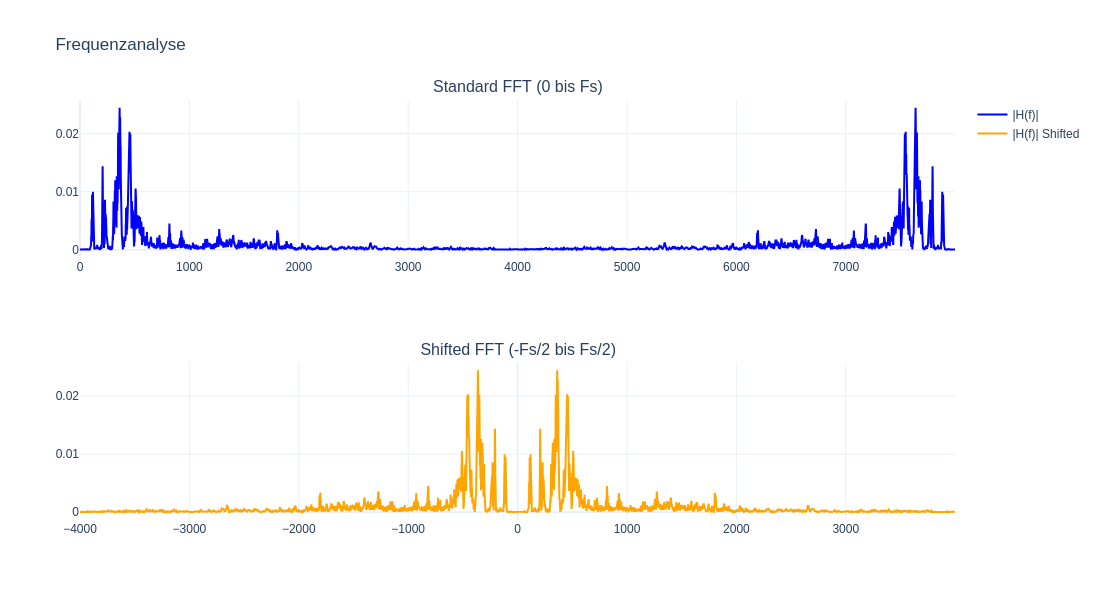

In [4]:
# FFT berechnen und normieren
y_fft = np.fft.fft(y) / n_samples

# Frequenzvektor (0 bis fs)
f = np.arange(0, n_samples) * fs / n_samples

# Shifted Version (Zentriert um 0 Hz)
y_fft_shifted = np.fft.fftshift(y_fft)
f_shifted = np.fft.fftshift(np.fft.fftfreq(n_samples, d=1 / fs))

# Visualisierung Spektrum
fig = make_subplots(
    rows=2,
    cols=1,
    subplot_titles=("Standard FFT (0 bis Fs)", "Shifted FFT (-Fs/2 bis Fs/2)"),
)
fig.add_trace(
    go.Scatter(x=f, y=np.abs(y_fft), name="|H(f)|", line=dict(color="blue")),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=f_shifted,
        y=np.abs(y_fft_shifted),
        name="|H(f)| Shifted",
        line=dict(color="orange"),
    ),
    row=2,
    col=1,
)
fig.update_layout(
    height=600, title="Frequenzanalyse", hovermode="x unified", template="plotly_white"
)
fig.show()

## b) Amplitude und Phase (Zoom)

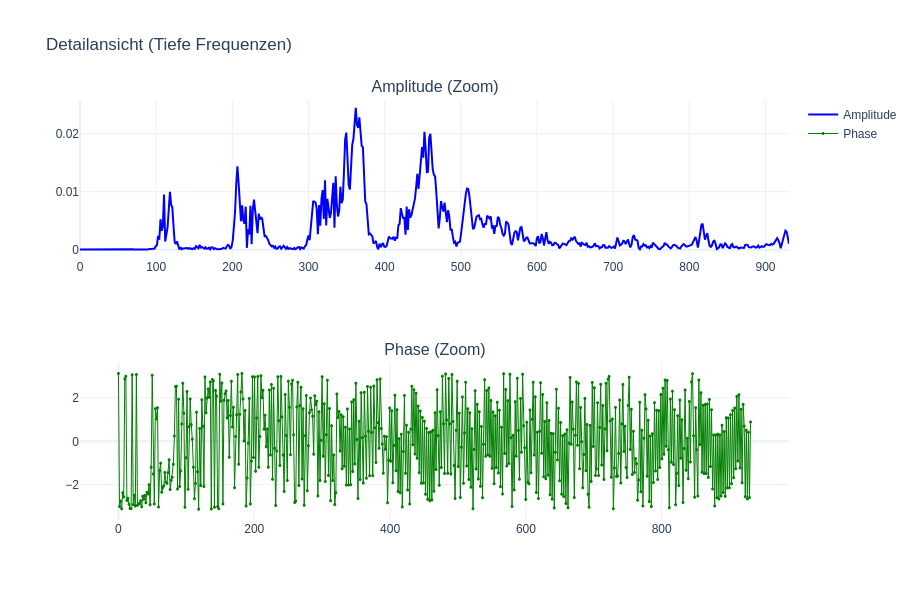

In [5]:
amplitude = np.abs(y_fft)
phase = np.angle(y_fft)

# Zoom in die tiefen Frequenzen (erste 600 Bins)
zoom_idx = 600

fig = make_subplots(rows=2, cols=1, subplot_titles=("Amplitude (Zoom)", "Phase (Zoom)"))
fig.add_trace(
    go.Scatter(
        x=f[:zoom_idx],
        y=amplitude[:zoom_idx],
        name="Amplitude",
        line=dict(color="blue"),
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=f[:zoom_idx],
        y=phase[:zoom_idx],
        name="Phase",
        mode="markers+lines",
        line=dict(color="green", width=1),
        marker=dict(size=3),
    ),
    row=2,
    col=1,
)
fig.update_layout(
    height=600, title="Detailansicht (Tiefe Frequenzen)", template="plotly_white"
)
fig.show()

## c) Random Amplitude / Phase Experiment (Das Wichtigste!)

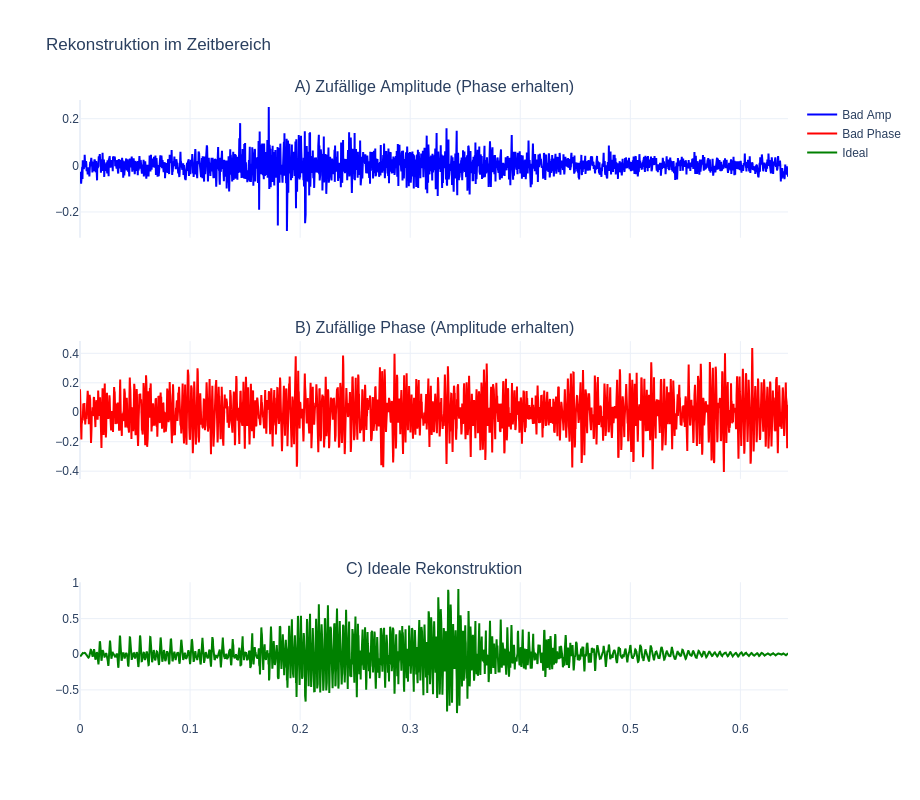

In [6]:
# Zeitvektor für Plots
t = np.linspace(0, (n_samples - 1) / fs, n_samples)

np.random.seed(42)

# Zufalls-Komponenten erzeugen
rand_amp = 1e-3 * np.random.rand(n_samples)
rand_phase = np.var(phase) * np.random.rand(n_samples) * 2 * np.pi

# Spektren manipulieren
# Fall A: Amplitude kaputt (Rauschen), Phase original
y_fft_bad_amp = rand_amp * np.exp(1j * phase)

# Fall B: Amplitude original, Phase kaputt (Zufall)
y_fft_bad_phase = amplitude * np.exp(1j * rand_phase)

# Fall C: Ideal (Kontrolle)
y_fft_ideal = amplitude * np.exp(1j * phase)

# Rücktransformation (IFFT)
# Wir müssen wieder mit n_samples multiplizieren, da wir oben geteilt hatten
y_rec_bad_amp = np.real(np.fft.ifft(y_fft_bad_amp * n_samples))
y_rec_bad_phase = np.real(np.fft.ifft(y_fft_bad_phase * n_samples))
y_rec_ideal = np.real(np.fft.ifft(y_fft_ideal * n_samples))

# Visualisierung Zeitbereich
step = max(1, int(n_samples / 2000))  # Downsampling für Performance
fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    subplot_titles=(
        "A) Zufällige Amplitude (Phase erhalten)",
        "B) Zufällige Phase (Amplitude erhalten)",
        "C) Ideale Rekonstruktion",
    ),
)

fig.add_trace(
    go.Scatter(
        x=t[::step], y=y_rec_bad_amp[::step], name="Bad Amp", line=dict(color="blue")
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=t[::step], y=y_rec_bad_phase[::step], name="Bad Phase", line=dict(color="red")
    ),
    row=2,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=t[::step], y=y_rec_ideal[::step], name="Ideal", line=dict(color="green")
    ),
    row=3,
    col=1,
)
fig.update_layout(
    height=800, title="Rekonstruktion im Zeitbereich", template="plotly_white"
)
fig.show()

## Hörtest

In [8]:
print("1. Phase erhalten (Amplitude verrauscht) -> Sprache meist noch verständlich:")
display(Audio(y_rec_bad_amp, rate=fs))

print("\n2. Amplitude erhalten (Phase zerstört) -> Nur Rauschen, keine Sprache:")
display(Audio(y_rec_bad_phase, rate=fs))

print("\n3. Ideal:")
display(Audio(y_rec_ideal, rate=fs))

1. Phase erhalten (Amplitude verrauscht) -> Sprache meist noch verständlich:



2. Amplitude erhalten (Phase zerstört) -> Nur Rauschen, keine Sprache:



3. Ideal:
